# Regression

- Author: Sydney Sailors
- Date: 2026-07
- Dataset: Medical Cost Prediction
- Target: annual_medical_cost

Run all cells top to bottom (**Run All**) before pushing to GitHub.

## M4. Regression

This notebook fits a line and computes the numbers analysts use to judge a fit:

- R-squared
- RMSE
- residuals
  
It shows how complexity changes train vs. test error. 

The analyst decides whether the fit is "good" and 
how much complexity is right. 
Code calculates values, but the analyst decides.

Every time we fit a model, we use the same shape: 
setup, load, prepare, model, evaluate, summarize.

Judgment always remains with the analyst.

## Overview

This project uses the Medical Cost Prediction dataset.
We choose to predict the target `annual_medical_cost`.
This target is a **numeric** variable (rather than a discrete category), so we have a:

- supervised ML problem (because we've chosen a target)
- a regression problem (because our target is numeric)

This model uses `previous_year_cost` and `age` as predictor variables to predict a patient's annual medical costs. 

## A. Prepare the Project Environment (.venv/)

- Open one project in VS Code at a time.
- Prepare the .venv/: specify Python version and install / upgrade dependencies listed in `pyproject.toml`.
- Open an integrated terminal (PowerShell if Windows) in the **root project** folder and run:

```shell
uv self update
uv python pin 3.14
uv lock --upgrade
uv sync --extra dev --extra docs --upgrade
```

## B. Select the Notebook Kernel

- Click on the **Select Kernel** name in the top-right corner of the notebook interface.
- Choose Python Environments... /
- Choose the recommended local .venv/ from the drop-down menu.
- This will create a new kernel for the notebook and allow the notebook to use packages installed in the .venv/ environment.

## C. Working in Notebooks (Custom Notes)

- To run a cell, press **Ctrl+Enter** (or **Cmd+Enter** on Mac) when done editing the cell.
- Change the type of a cell (e.g., code or markdown) by looking in the lower left corner of the notebook interface.
- Rearrange cells by dragging and dropping them within the notebook.

See [Run Jupyter Notebooks](https://denisecase.github.io/pro-analytics-02/workflow-b-apply-example-project/run-notebook/) for:

- how to **copy a notebook**
- how to release a `project.log` file
- how to deal with a **stuck kernel**
- etc.

## Section 0. When to Use Regression, and How We Judge It

Use **regression** when the target is a **number** - mass, price, temperature,
demand. (A category target is classification, Module 3.)

We judge a regression on held-out data, with:

- **R-squared** - the fraction of the variation in the target the model explains
  (roughly 0 to 1; higher is more).
- **RMSE** - root mean squared error, the typical size of a miss, in the target's units.
- **residual plot** - actual minus predicted. If a straight line fits well, residuals
  scatter randomly around zero with no pattern. A curve or a funnel says the line is
  the wrong shape - itself a useful finding.

**Over- vs. under-fitting:** a model too simple **underfits** (misses real structure;
poor on both train and test). A model too complex **overfits** (memorizes the training
data; great on train, worse on test). You detect it by comparing train and test error
as complexity changes - Section 6.

## Section 1. Project Setup and Imports

In [17]:
# === Section 1a. DECLARE IMPORTS ===

from importlib.metadata import version  # to verify
import logging  # for type hinting
import platform  # to verify
from typing import Final  # for type hinting

from datafun_toolkit.logger import get_logger, log_header
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures

# === Section 1b. CONFIGURE LOGGER ONCE PER NOTEBOOK ===

LOG: logging.Logger = get_logger("M04", level="DEBUG")
log_header(LOG, "M04")

# === Section 1c. USE THE LOGGER TO VERIFY IMPORTS ===

# If any do NOT return a version number, then that package is not installed correctly.
# Check your pyproject.toml and re-run environment setup commands.

LOG.info("Confirming installation:")
LOG.info(f"  python:       {platform.python_version()}")
LOG.info(f"  pandas:       {version('pandas')}")
LOG.info(f"  numpy:        {version('numpy')}")
LOG.info(f"  scikit-learn: {version('scikit-learn')}")
LOG.info(f"  seaborn:      {version('seaborn')}")
LOG.info(f"  matplotlib:   {version('matplotlib')}")

# === Section 1d. SET PANDAS DISPLAY CONFIGURATION (helps in notebooks) ===

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)

2026-07-26 14:14:23 | INFO | M04 | === RUN START ===
2026-07-26 14:14:23 | INFO | M04 | project=M04
2026-07-26 14:14:23 | INFO | M04 | repo_dir=ml-04-regression
2026-07-26 14:14:23 | INFO | M04 | python=3.14.5
2026-07-26 14:14:23 | INFO | M04 | os=Darwin 20.6.0
2026-07-26 14:14:23 | INFO | M04 | shell=zsh
2026-07-26 14:14:23 | INFO | M04 | cwd=notebooks
2026-07-26 14:14:23 | INFO | M04 | github_actions=False
2026-07-26 14:14:23 | INFO | M04 | Confirming installation:
2026-07-26 14:14:23 | INFO | M04 |   python:       3.14.5
2026-07-26 14:14:23 | INFO | M04 |   pandas:       3.0.5
2026-07-26 14:14:23 | INFO | M04 |   numpy:        2.5.1
2026-07-26 14:14:23 | INFO | M04 |   scikit-learn: 1.9.0
2026-07-26 14:14:23 | INFO | M04 |   seaborn:      0.13.2
2026-07-26 14:14:23 | INFO | M04 |   matplotlib:   3.11.1


## Section 2. Load and Prepare the Data

In [18]:
# === Section 2. Load and Prepare the Data ===

# We are loading data from Seaborn's built-in datasets,
# which are small datasets included with the Seaborn library
# for practice and demonstration purposes.
# They are listed above with sns.get_dataset_names().
# Experiment with different ones to see what they contain.
# You can also load from CSV files, databases, or APIs and process is similar.

# CUSTOM: In this example, I load a Seaborn dataset by name (no external CSV).
# Change to explore a different dataset.
DATASET_NAME: Final[str] = "Medical Cost Prediction"

LOG.info(f"Loading dataset: {DATASET_NAME}")
df: pd.DataFrame = pd.read_csv("../data/raw/medical_cost_prediction_dataset.csv")
LOG.info(f"Loaded: {df.shape[0]} rows (instances), {df.shape[1]} columns")


# CUSTOM: ANALYST CHOICE - one numeric feature (x) and one numeric target (y).
# This pairing is expected to be close to a straight line; we still fit and look.
FEATURE_COLS = ["previous_year_cost", "age"]
TARGET_COL: Final[str] = "annual_medical_cost"

FEATURE_LABEL: Final[str] = "Previous Year Cost ($)"
TARGET_LABEL: Final[str] = "Annual Medical Cost ($)"

df_model: pd.DataFrame = df.dropna(subset=FEATURE_COLS + [TARGET_COL]).copy()
LOG.info(f"Original rows: {df.shape[0]}  Model rows: {df_model.shape[0]}")

2026-07-26 14:14:23 | INFO | M04 | Loading dataset: Medical Cost Prediction
2026-07-26 14:14:23 | INFO | M04 | Loaded: 5000 rows (instances), 20 columns
2026-07-26 14:14:23 | INFO | M04 | Original rows: 5000  Model rows: 5000


## Section 3. Split into Train and Test


ANALYST CHOICE

We hold out a test set the model never sees
so R-squared and RMSE reflect new data. 

Without a held-out set we cannot tell a good fit from memorization.

In [19]:
# === Section 3. Split into Train and Test ===

# CUSTOM: ANALYST CHOICE

# Reproducibility for the split and the model.
# Pick any integer, but keep it the same to get the same results.
RANDOM_STATE: Final[int] = 42

"""Build X (2-D) and y (1-D), then split into train and test.

WHY: scikit-learn wants X as shape (n, 1) and y as shape (n,).

Double brackets give a DataFrame (2-D);
single brackets give a Series (1-D).
"""

# Declare X to hold the feature values,
# which will be used for model fitting.
X: np.ndarray = df_model[FEATURE_COLS].to_numpy()

# Declare y to hold the target values,
# which will be used for model fitting.
y: np.ndarray = df_model[TARGET_COL].to_numpy()

# Declare X_train to hold the training feature values,
# which will be used for model fitting.
X_train: np.ndarray

# Declare X_test to hold the test feature values,
# which will be used for evaluation after model training.
X_test: np.ndarray

# Declare y_train to hold the training target values,
# which will be used for model fitting.
y_train: np.ndarray

# Declare y_test to hold the test target values,
# which will be used for evaluation after model training.
y_test: np.ndarray

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)
LOG.info(f"Train instances: {len(X_train)}")
LOG.info(f"Test instances: {len(X_test)}")

2026-07-26 14:14:23 | INFO | M04 | Train instances: 4000
2026-07-26 14:14:23 | INFO | M04 | Test instances: 1000


## Section 4. Fit a Straight Line

In [20]:
# === Section 4. Fit a Straight Line ===


"""
Fit y = slope * x + intercept with scikit-learn.

WHY: create -> .fit() -> read results / .predict()
 is the same pattern for every scikit-learn model.

The model exposes .coef_ (slope) and .intercept_.
"""

LOG.info("Fitting a linear regression (scikit-learn)")

# create a linear regression model object (untrained)
model = LinearRegression()

# fit the model to the training data (learn the slope and intercept)
model.fit(X_train, y_train)

# retrieve the results (slope and intercept) and log them

slope: float = float(model.coef_[0])
intercept: float = float(model.intercept_)

LOG.info(f"Fitted line: {TARGET_COL} = {slope:.6g} * {FEATURE_COLS} + {intercept:.6g}")

2026-07-26 14:14:23 | INFO | M04 | Fitting a linear regression (scikit-learn)
2026-07-26 14:14:23 | INFO | M04 | Fitted line: annual_medical_cost = 0.112465 * ['previous_year_cost', 'age'] + 6254.58


## Section 5. Evaluate the Model Fit

2026-07-26 14:14:23 | INFO | M04 | Fit numbers on the TEST set (for you to interpret):
2026-07-26 14:14:23 | INFO | M04 |   R-squared: 0.0053
2026-07-26 14:14:23 | INFO | M04 |   RMSE:      6965.5  (in units of Annual Medical Cost ($))


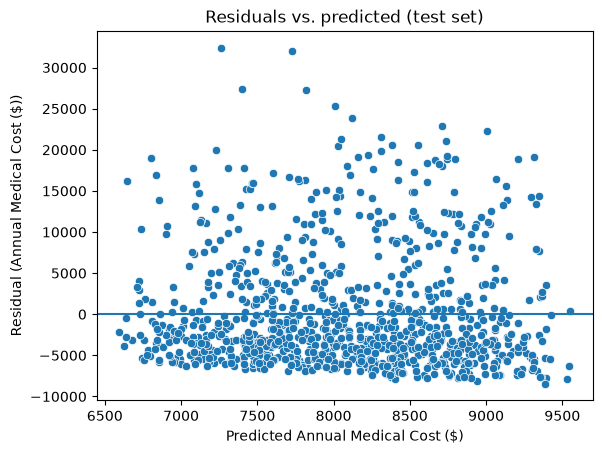

In [21]:
# === Section 5. Evaluate the Model Fit ===

# With regression, we use  R-squared, RMSE, and Residuals

"""
Report test R-squared and RMSE, and show a residual plot.

WHY: These are how the analyst decides
whether the line is a fair description.

This reports them on held-out data;
it does NOT declare the fit good or bad.

The analyst uses the numbers and the residual plot to decide.
"""

y_hat: np.ndarray = model.predict(X_test)

# Use float() to convert from numpy types to native Python types
residuals: np.ndarray = y_test - y_hat
r_squared: float = float(model.score(X_test, y_test))
rmse: float = float(np.sqrt(np.mean(residuals**2)))

LOG.info("Fit numbers on the TEST set (for you to interpret):")
LOG.info(f"  R-squared: {r_squared:.4f}")
LOG.info(f"  RMSE:      {rmse:.6g}  (in units of {TARGET_LABEL})")

# Residual plot: random scatter around 0 means a straight line fits well.

# Start a new figure
plt.figure()

# Create a scatter plot of residuals vs. predicted values
sns.scatterplot(x=y_hat, y=residuals)

# Add a horizontal line at y=0 to help visualize the residuals
plt.axhline(0)

# Label the axes and add a title
plt.xlabel(f"Predicted {TARGET_LABEL}")
plt.ylabel(f"Residual ({TARGET_LABEL})")
plt.title("Residuals vs. predicted (test set)")

# show the plot
plt.show()

### Interpretation

The residual plot does not show a strong 
linear pattern. There is a wide spread
of residuals, but several large positive 
residuals indicate that the model 
underpredicts some patients with very high 
annual medical costs. 

The low R-squared value of 0.0053 means the model 
explains about 0.5% of the variation in annual 
medical costs. 

The RMSE of $6,965.50 means there are large 
prediction errors. 

In this case, it looks like a straight line is
not a good model. A simple linear regression 
using only `previous_year_cost` and `age` do 
not provide a strong fit for this dataset. 
Using more predictor variables could improve
predictor performance. 

## Section 6. Detect Over- and Under-Fitting

Fit polynomials of increasing **degree** 
(degree 1 is the straight line) and plot
train vs. test RMSE. 

Underfitting shows as both errors high; 
overfitting shows as train RMSE falling while test RMSE rises. 

The best degree is where **test error is lowest** 
and the train/test gap is small.

The analyst decides which degree that is.

2026-07-26 14:16:22 | DEBUG | M04 | degree= 1 train RMSE=7058.79 test RMSE=6965.5
2026-07-26 14:16:22 | DEBUG | M04 | degree= 2 train RMSE=7056.22 test RMSE=6962.86
2026-07-26 14:16:22 | DEBUG | M04 | degree= 3 train RMSE=7056.66 test RMSE=6961.91
2026-07-26 14:16:22 | DEBUG | M04 | degree= 4 train RMSE=7058.02 test RMSE=6959.95
2026-07-26 14:16:22 | DEBUG | M04 | degree= 5 train RMSE=7060.13 test RMSE=6957.02
2026-07-26 14:16:22 | DEBUG | M04 | degree= 6 train RMSE=7062.25 test RMSE=6954.36
2026-07-26 14:16:22 | DEBUG | M04 | degree= 7 train RMSE=7064.16 test RMSE=6952.88
2026-07-26 14:16:22 | DEBUG | M04 | degree= 8 train RMSE=7065.89 test RMSE=6952.67
2026-07-26 14:16:22 | DEBUG | M04 | degree= 9 train RMSE=7067.49 test RMSE=6953.48
2026-07-26 14:16:22 | DEBUG | M04 | degree=10 train RMSE=7068.99 test RMSE=6954.98


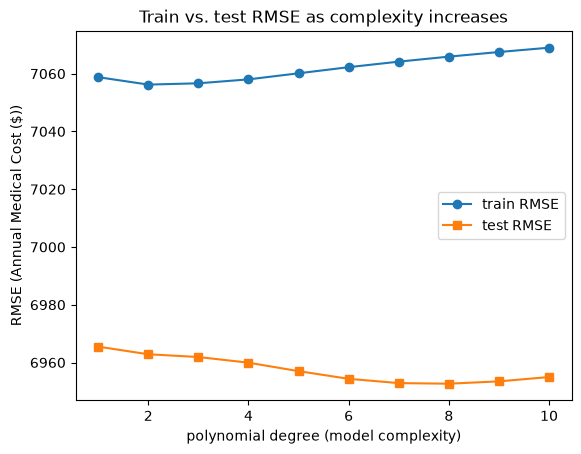

In [24]:
# === Section 6. Detect Over- and Under-Fitting ===

"""Show train vs. test RMSE as polynomial degree increases.

WHY: Error is not a fixed property of "the model"; it moves with complexity.
Watching train and test diverge is how you detect over- and under-fitting and
pick complexity on purpose. numpy fits the polynomial; nothing hidden.
"""

MAX_SWEEP: Final[int] = 10

degrees: list[int] = list(range(1, MAX_SWEEP + 1))
train_rmse: list[float] = []
test_rmse: list[float] = []

for degree in degrees:
    # Create polynomial features
    poly = PolynomialFeatures(degree=degree)

    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)

    # Fit regression model
    model = LinearRegression()
    model.fit(X_train_poly, y_train)

    # Predictions
    train_pred = model.predict(X_train_poly)
    test_pred = model.predict(X_test_poly)

    # RMSE calculations
    train_rmse.append(float(np.sqrt(mean_squared_error(y_train, train_pred))))

    test_rmse.append(float(np.sqrt(mean_squared_error(y_test, test_pred))))

    LOG.debug(
        f"degree={degree:2d} "
        f"train RMSE={train_rmse[-1]:.6g} "
        f"test RMSE={test_rmse[-1]:.6g}"
    )

# start a new figure
plt.figure()

# Plot the train and test RMSE against the polynomial degree
# to visualize overfitting and underfitting.
plt.plot(degrees, train_rmse, marker="o", label="train RMSE")
plt.plot(degrees, test_rmse, marker="s", label="test RMSE")

# Label the axes and add a title
plt.xlabel("polynomial degree (model complexity)")
plt.ylabel(f"RMSE ({TARGET_LABEL})")
plt.title("Train vs. test RMSE as complexity increases")

# Add a legend
plt.legend()

# Show the plot
plt.show()

### Interpretation

As the degree increases, the RMSE decreases
slightly. The lowest RMSE is at a degree of 8
and there is no strong evidence of overfitting. 
A degree of 8 would be the best option, but 
more features would likely improve the model 
more than increasing the complexity. 

## Section 7. Summary and Next Steps

First, output key information (may use Python)
Second, provide your narrative, conclusions, and next steps (in Markdown)

In [23]:
# === Python Summary ===


"""Record what was fit and the judgment still owed."""
slope: float = float(model.coef_[0])
intercept: float = float(model.intercept_)
LOG.info("========================")
LOG.info("SUMMARY")
LOG.info("========================")
LOG.info(f"Dataset:  {DATASET_NAME}")
LOG.info(f"Feature:  {FEATURE_COLS}  ->  Target: {TARGET_COL}  (regression)")
LOG.info(f"Line:     {TARGET_COL} = {slope:.6g} * {FEATURE_COLS} + {intercept:.6g}")
LOG.info("========================")

2026-07-26 14:14:25 | INFO | M04 | ========================
2026-07-26 14:14:25 | INFO | M04 | SUMMARY
2026-07-26 14:14:25 | INFO | M04 | ========================
2026-07-26 14:14:25 | INFO | M04 | Dataset:  Medical Cost Prediction
2026-07-26 14:14:25 | INFO | M04 | Feature:  ['previous_year_cost', 'age']  ->  Target: annual_medical_cost  (regression)
2026-07-26 14:14:25 | INFO | M04 | Line:     annual_medical_cost = -1.24718e-47 * ['previous_year_cost', 'age'] + 7658.81
2026-07-26 14:14:25 | INFO | M04 | ========================


## Reminder: Run All before pushing to GitHub

Before saving a notebook (and running git add-commit-push), click 'Run All' to generate all outputs and display them in the notebook.

Follow our [pro-analytics-02](https://denisecase.github.io/pro-analytics-02/) common workflows.

Your README.md should have a description, a link to your executed notebook, and a list of commands (updated as you add your custom description, instructions, and commands).

Your docs/ folder should document your custom project analysis in the `docs/index.md` summary.
